<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/day_19_hardware_aware_nas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hardware-Aware Neural Architecture Search

Here, I attempt to extend NAS to optimise for real hardware constraints, not just accuracy, but latency, energy, and memory. Standard NAS finds accurate architectures that may be impractically slow on target devices. Hardware-aware NAS incorporates device-specific costs into the search objective. I implement latency lookup tables (pre-measured op costs), latency predictors (learned models), multi-objective optimization (Pareto frontiers), and hardware-specific search strategies. I explore how the same accuracy target yields different optimal architectures for GPU vs mobile vs edge devices.


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List, Dict, Tuple, Union, Callable
from dataclasses import dataclass, field
from abc import ABC, abstractmethod
from collections import defaultdict
import random
import copy
import time
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Hardware Cost Models

Hardware cost models estimate the real-world cost (latency, energy, memory) of operations without running on actual hardware.

In [20]:
@dataclass
class HardwareSpec:
    """
    Hardware specification for cost modeling.

    Different devices have different characteristics:
    - GPU: High parallelism, memory bandwidth limited
    - CPU: Lower parallelism, cache-sensitive
    - Mobile: Power-constrained, limited memory
    - Edge: Extremely constrained, no GPU
    """
    name: str
    # Relative speed factors (1.0 = baseline GPU)
    conv_speed: float = 1.0
    depthwise_speed: float = 1.0
    pointwise_speed: float = 1.0
    dense_speed: float = 1.0
    attention_speed: float = 1.0
    # Memory bandwidth (GB/s)
    memory_bandwidth: float = 900.0
    # Peak compute (GFLOPS)
    peak_flops: float = 15000.0
    # Power budget (Watts)
    power_budget: float = 300.0


# Pre-defined hardware profiles
HARDWARE_PROFILES = {
    'gpu_v100': HardwareSpec(
        name='NVIDIA V100',
        conv_speed=1.0, depthwise_speed=0.8, pointwise_speed=1.2,
        dense_speed=1.5, attention_speed=1.0,
        memory_bandwidth=900, peak_flops=15000, power_budget=300
    ),
    'gpu_mobile': HardwareSpec(
        name='Mobile GPU (Adreno)',
        conv_speed=0.1, depthwise_speed=0.15, pointwise_speed=0.12,
        dense_speed=0.08, attention_speed=0.05,
        memory_bandwidth=25, peak_flops=500, power_budget=5
    ),
    'cpu_server': HardwareSpec(
        name='Intel Xeon',
        conv_speed=0.05, depthwise_speed=0.2, pointwise_speed=0.1,
        dense_speed=0.1, attention_speed=0.02,
        memory_bandwidth=100, peak_flops=2000, power_budget=150
    ),
    'cpu_mobile': HardwareSpec(
        name='ARM Cortex-A76',
        conv_speed=0.02, depthwise_speed=0.1, pointwise_speed=0.05,
        dense_speed=0.03, attention_speed=0.01,
        memory_bandwidth=30, peak_flops=100, power_budget=3
    ),
    'edge_npu': HardwareSpec(
        name='Edge NPU',
        conv_speed=0.3, depthwise_speed=0.5, pointwise_speed=0.4,
        dense_speed=0.2, attention_speed=0.1,
        memory_bandwidth=10, peak_flops=4000, power_budget=2
    ),
    'edge_mcu': HardwareSpec(
        name='Cortex-M7 MCU',
        conv_speed=0.001, depthwise_speed=0.005, pointwise_speed=0.002,
        dense_speed=0.001, attention_speed=0.0005,
        memory_bandwidth=0.5, peak_flops=1, power_budget=0.5
    ),
}

print("Available hardware profiles:")
for name, spec in HARDWARE_PROFILES.items():
    print(f"  {name}: {spec.name} ({spec.peak_flops} GFLOPS, {spec.power_budget}W)")

Available hardware profiles:
  gpu_v100: NVIDIA V100 (15000 GFLOPS, 300W)
  gpu_mobile: Mobile GPU (Adreno) (500 GFLOPS, 5W)
  cpu_server: Intel Xeon (2000 GFLOPS, 150W)
  cpu_mobile: ARM Cortex-A76 (100 GFLOPS, 3W)
  edge_npu: Edge NPU (4000 GFLOPS, 2W)
  edge_mcu: Cortex-M7 MCU (1 GFLOPS, 0.5W)


In [21]:
class HardwareCostModel:
    """
    Analytical cost model for estimating latency on different hardware.

    Uses roofline model: latency = max(compute_time, memory_time)
    """

    def __init__(self, hardware: HardwareSpec):
        self.hardware = hardware

    def conv2d_latency(self, in_channels: int, out_channels: int,
                       kernel_size: int, spatial: int, stride: int = 1,
                       groups: int = 1) -> float:
        """
        Estimate Conv2d latency in milliseconds.

        FLOPs = 2 * H_out * W_out * C_out * C_in * K * K / groups
        Memory = params + activations
        """
        out_spatial = spatial // stride

        # Compute FLOPs
        flops = 2 * out_spatial * out_spatial * out_channels * \
                (in_channels // groups) * kernel_size * kernel_size

        # Memory access (bytes)
        params_bytes = in_channels * out_channels * kernel_size * kernel_size * 4 // groups
        input_bytes = in_channels * spatial * spatial * 4
        output_bytes = out_channels * out_spatial * out_spatial * 4
        memory_bytes = params_bytes + input_bytes + output_bytes

        # Roofline model
        compute_time = flops / (self.hardware.peak_flops * 1e9) * 1000  # ms
        memory_time = memory_bytes / (self.hardware.memory_bandwidth * 1e9) * 1000  # ms

        # Apply hardware-specific speed factor
        if groups == in_channels:
            speed_factor = self.hardware.depthwise_speed
        elif kernel_size == 1:
            speed_factor = self.hardware.pointwise_speed
        else:
            speed_factor = self.hardware.conv_speed

        base_latency = max(compute_time, memory_time)
        return base_latency / speed_factor

    def dense_latency(self, in_features: int, out_features: int) -> float:
        """
        Estimate Linear layer latency.
        """
        flops = 2 * in_features * out_features
        memory_bytes = (in_features * out_features + in_features + out_features) * 4

        compute_time = flops / (self.hardware.peak_flops * 1e9) * 1000
        memory_time = memory_bytes / (self.hardware.memory_bandwidth * 1e9) * 1000

        return max(compute_time, memory_time) / self.hardware.dense_speed

    def attention_latency(self, seq_len: int, d_model: int, n_heads: int) -> float:
        """
        Estimate self-attention latency.
        """
        # QKV projection + attention + output projection
        proj_flops = 4 * seq_len * d_model * d_model  # Q, K, V, O projections
        attn_flops = 2 * n_heads * seq_len * seq_len * (d_model // n_heads)  # QK^T and attn*V
        total_flops = proj_flops + attn_flops

        # Memory for attention matrix
        attn_memory = n_heads * seq_len * seq_len * 4
        proj_memory = 4 * d_model * d_model * 4
        memory_bytes = attn_memory + proj_memory

        compute_time = total_flops / (self.hardware.peak_flops * 1e9) * 1000
        memory_time = memory_bytes / (self.hardware.memory_bandwidth * 1e9) * 1000

        return max(compute_time, memory_time) / self.hardware.attention_speed

    def pooling_latency(self, channels: int, spatial: int,
                        kernel_size: int, stride: int) -> float:
        """
        Estimate pooling latency (very fast, memory-bound).
        """
        out_spatial = spatial // stride
        memory_bytes = channels * (spatial * spatial + out_spatial * out_spatial) * 4
        return memory_bytes / (self.hardware.memory_bandwidth * 1e9) * 1000

In [22]:
# Compare operation costs across hardware

print("Operation Latency Comparison (ms)")
print("=" * 80)

# Test configuration
configs = [
    ('Conv 3×3 (64→128)', lambda m: m.conv2d_latency(64, 128, 3, 32)),
    ('Depthwise 3×3 (128)', lambda m: m.conv2d_latency(128, 128, 3, 32, groups=128)),
    ('Pointwise 1×1 (128→256)', lambda m: m.conv2d_latency(128, 256, 1, 32)),
    ('Dense (512→512)', lambda m: m.dense_latency(512, 512)),
    ('Attention (256, d=128)', lambda m: m.attention_latency(256, 128, 8)),
]

hardware_list = ['gpu_v100', 'cpu_server', 'gpu_mobile', 'cpu_mobile', 'edge_npu']

print(f"\n{'Operation':<25}", end='')
for hw in hardware_list:
    print(f"{hw:>12}", end='')
print()
print("-" * 85)

for name, fn in configs:
    print(f"{name:<25}", end='')
    for hw in hardware_list:
        model = HardwareCostModel(HARDWARE_PROFILES[hw])
        latency = fn(model)
        print(f"{latency:>11.3f}ms", end='')
    print()

Operation Latency Comparison (ms)

Operation                    gpu_v100  cpu_server  gpu_mobile  cpu_mobile    edge_npu
-------------------------------------------------------------------------------------
Conv 3×3 (64→128)              0.010ms      1.510ms      3.020ms     75.497ms      0.360ms
Depthwise 3×3 (128)            0.001ms      0.053ms      0.281ms      0.351ms      0.211ms
Pointwise 1×1 (128→256)        0.004ms      0.336ms      1.118ms     13.422ms      0.426ms
Dense (512→512)                0.001ms      0.105ms      0.526ms      1.170ms      0.526ms
Attention (256, d=128)         0.003ms      1.180ms      1.887ms     33.554ms      2.359ms


Latency Lookup Tables

Instead of analytical models, we can pre-measure operation latencies on actual hardware and store them in lookup tables. This is more accurate but requires access to target hardware.

In [23]:
class LatencyLookupTable:
    """
    Lookup table for operation latencies.

    In practice, these would be measured on actual hardware.
    Here we simulate with analytical model + noise.
    """

    def __init__(self, hardware: str = 'gpu_v100'):
        self.hardware = hardware
        self.cost_model = HardwareCostModel(HARDWARE_PROFILES[hardware])
        self.table = {}  # Cache for measured latencies

    def _measure_op(self, op_type: str, config: Tuple) -> float:
        """
        Simulate measuring operation latency.
        In practice, this would run the op on real hardware.
        """
        if op_type == 'conv':
            c_in, c_out, k, spatial, stride, groups = config
            base = self.cost_model.conv2d_latency(c_in, c_out, k, spatial, stride, groups)
        elif op_type == 'dense':
            in_f, out_f = config
            base = self.cost_model.dense_latency(in_f, out_f)
        elif op_type == 'pool':
            c, spatial, k, stride = config
            base = self.cost_model.pooling_latency(c, spatial, k, stride)
        else:
            base = 0.001  # Unknown op

        # Add measurement noise (±10%)
        noise = np.random.uniform(0.9, 1.1)
        return base * noise

    def get_latency(self, op_type: str, config: Tuple) -> float:
        """
        Get latency from table or measure if not cached.
        """
        key = (op_type, config)
        if key not in self.table:
            self.table[key] = self._measure_op(op_type, config)
        return self.table[key]

    def build_table_for_search_space(self, channels: List[int],
                                      spatials: List[int],
                                      kernel_sizes: List[int] = [1, 3, 5]):
        """
        Pre-build lookup table for a search space.
        """
        count = 0

        for c_in in channels:
            for c_out in channels:
                for k in kernel_sizes:
                    for s in spatials:
                        # Standard conv
                        self.get_latency('conv', (c_in, c_out, k, s, 1, 1))
                        # Depthwise conv
                        if c_in == c_out:
                            self.get_latency('conv', (c_in, c_out, k, s, 1, c_in))
                        count += 2

        print(f"Built lookup table with {len(self.table)} entries")
        return self

In [24]:
# Build lookup tables for different hardware

print("Building Latency Lookup Tables")
print("=" * 50)

channels = [16, 32, 64, 128]
spatials = [32, 16, 8]

lut_gpu = LatencyLookupTable('gpu_v100').build_table_for_search_space(channels, spatials)
lut_mobile = LatencyLookupTable('cpu_mobile').build_table_for_search_space(channels, spatials)
lut_edge = LatencyLookupTable('edge_npu').build_table_for_search_space(channels, spatials)

# Compare some entries
print("\nSample latencies (Conv 64→64, 3×3, 16×16):")
config = (64, 64, 3, 16, 1, 1)
print(f"  GPU: {lut_gpu.get_latency('conv', config):.4f}ms")
print(f"  Mobile: {lut_mobile.get_latency('conv', config):.4f}ms")
print(f"  Edge NPU: {lut_edge.get_latency('conv', config):.4f}ms")

Building Latency Lookup Tables
Built lookup table with 180 entries
Built lookup table with 180 entries
Built lookup table with 180 entries

Sample latencies (Conv 64→64, 3×3, 16×16):
  GPU: 0.0013ms
  Mobile: 9.9468ms
  Edge NPU: 0.0849ms


Latency Predictors

For large search spaces, we can train a neural network to predict latency from architecture encoding. This is faster than measuring and more accurate than analytical models.

In [25]:
class LatencyPredictor(nn.Module):
    """
    Neural network that predicts architecture latency.

    Input: Architecture encoding (operations, channels, connections)
    Output: Predicted latency

    Trained on measured latencies from actual hardware.
    """

    def __init__(self, num_ops: int, num_nodes: int, hidden_dim: int = 64):
        super().__init__()

        self.num_ops = num_ops
        self.num_nodes = num_nodes

        # Encode each edge's operation as embedding
        self.op_embedding = nn.Embedding(num_ops, hidden_dim)

        # Process architecture
        num_edges = sum(i + 2 for i in range(num_nodes))  # Edges in cell
        input_dim = num_edges * hidden_dim

        self.predictor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus()  # Ensure positive latency
        )

    def forward(self, arch_encoding: torch.Tensor) -> torch.Tensor:
        """
        Args:
            arch_encoding: (batch, num_edges) tensor of operation indices

        Returns:
            (batch,) predicted latencies
        """
        # Embed operations
        embedded = self.op_embedding(arch_encoding)  # (batch, edges, hidden)
        embedded = embedded.flatten(1)  # (batch, edges * hidden)

        return self.predictor(embedded).squeeze(-1)


class LatencyDataset:
    """
    Dataset of (architecture, latency) pairs for training predictor.
    """

    def __init__(self, lut: LatencyLookupTable, num_ops: int, num_nodes: int):
        self.lut = lut
        self.num_ops = num_ops
        self.num_nodes = num_nodes
        self.num_edges = sum(i + 2 for i in range(num_nodes))

        self.architectures = []
        self.latencies = []

    def generate_samples(self, num_samples: int, base_channels: int = 32,
                         spatial: int = 16):
        """
        Generate random architectures and measure their latencies.
        """
        for _ in range(num_samples):
            # Random architecture (operation indices for each edge)
            arch = np.random.randint(0, self.num_ops, self.num_edges)

            # Estimate latency (sum of operation latencies)
            total_latency = 0
            for op_idx in arch:
                # Map op index to operation type and config
                if op_idx < 2:  # none, skip
                    latency = 0.001
                elif op_idx < 4:  # sep_conv
                    k = 3 if op_idx == 2 else 5
                    latency = self.lut.get_latency('conv',
                        (base_channels, base_channels, k, spatial, 1, base_channels))
                elif op_idx < 6:  # dil_conv
                    k = 3 if op_idx == 4 else 5
                    latency = self.lut.get_latency('conv',
                        (base_channels, base_channels, k, spatial, 1, base_channels)) * 1.2
                else:  # pooling
                    latency = self.lut.get_latency('pool',
                        (base_channels, spatial, 3, 1))

                total_latency += latency

            self.architectures.append(arch)
            self.latencies.append(total_latency)

        return self

    def get_tensors(self) -> Tuple[torch.Tensor, torch.Tensor]:
        return (torch.tensor(self.architectures, dtype=torch.long),
                torch.tensor(self.latencies, dtype=torch.float32))

In [26]:
# Train latency predictor

print("Training Latency Predictor")
print("=" * 50)

num_ops = 8  # Same as PRIMITIVES
num_nodes = 4

# Generate training data
dataset = LatencyDataset(lut_mobile, num_ops, num_nodes)
dataset.generate_samples(1000)
X, y = dataset.get_tensors()

print(f"Training samples: {len(X)}")
print(f"Latency range: {y.min():.3f} - {y.max():.3f} ms")

# Train predictor
predictor = LatencyPredictor(num_ops, num_nodes)
optimizer = torch.optim.Adam(predictor.parameters(), lr=0.01)

# Training loop
predictor.train()
for epoch in range(100):
    optimizer.zero_grad()
    pred = predictor(X)
    loss = F.mse_loss(pred, y)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: MSE = {loss.item():.6f}")

# Evaluate
predictor.eval()
with torch.no_grad():
    pred = predictor(X)
    mse = F.mse_loss(pred, y).item()
    mae = (pred - y).abs().mean().item()
    corr = np.corrcoef(pred.numpy(), y.numpy())[0, 1]

print(f"\nFinal metrics:")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.4f} ms")
print(f"  Correlation: {corr:.4f}")

Training Latency Predictor
Training samples: 1000
Latency range: 0.067 - 0.498 ms
Epoch 20: MSE = 0.073801
Epoch 40: MSE = 0.073801
Epoch 60: MSE = 0.073801
Epoch 80: MSE = 0.073801
Epoch 100: MSE = 0.073801

Final metrics:
  MSE: 0.073801
  MAE: 0.2622 ms
  Correlation: -0.0438


Multi-Objective NAS

Real deployment requires optimizing multiple objectives: accuracy AND latency AND energy AND memory. This leads to Pareto-optimal solutions.

In [27]:
@dataclass
class Architecture:
    """Architecture with multiple objectives."""
    encoding: np.ndarray  # Operation indices
    accuracy: float = 0.0
    latency: float = 0.0
    params: int = 0
    flops: int = 0
    energy: float = 0.0

    # Custom __eq__ and __hash__ for numpy array comparison
    def __eq__(self, other: object) -> bool:
        if not isinstance(other, Architecture):
            return NotImplemented
        return (
            np.array_equal(self.encoding, other.encoding) and
            self.accuracy == other.accuracy and
            self.latency == other.latency and
            self.params == other.params
        )

    def __hash__(self) -> int:
        # Use a hashable representation of the numpy array for hashing
        return hash((tuple(self.encoding), self.accuracy, self.latency, self.params))

    def dominates(self, other: 'Architecture') -> bool:
        """
        Check if this architecture Pareto-dominates another.

        Dominates if better or equal in all objectives, strictly better in at least one.
        Higher accuracy is better, lower latency/params/flops/energy is better.
        """
        dominated = (
            self.accuracy >= other.accuracy and
            self.latency <= other.latency and
            self.params <= other.params
        )
        strictly_better = (
            self.accuracy > other.accuracy or
            self.latency < other.latency or
            self.params < other.params
        )
        return dominated and strictly_better


def find_pareto_frontier(architectures: List[Architecture]) -> List[Architecture]:
    """
    Find Pareto-optimal architectures.

    An architecture is Pareto-optimal if no other architecture dominates it.
    """
    pareto = []

    for arch in architectures:
        # Check if any existing Pareto member dominates this one
        is_dominated = any(p.dominates(arch) for p in pareto)

        if not is_dominated:
            # Remove any Pareto members dominated by this one
            pareto = [p for p in pareto if not arch.dominates(p)]
            pareto.append(arch)

    return pareto


class MultiObjectiveNAS:
    """
    Multi-objective NAS using NSGA-II style evolution.

    Maintains population of Pareto-optimal solutions.
    """

    def __init__(self, num_ops: int, num_nodes: int,
                 latency_lut: LatencyLookupTable,
                 population_size: int = 50):
        self.num_ops = num_ops
        self.num_nodes = num_nodes
        self.num_edges = sum(i + 2 for i in range(num_nodes))
        self.latency_lut = latency_lut
        self.population_size = population_size
        self.population = []

    def _random_architecture(self) -> Architecture:
        """Generate random architecture."""
        encoding = np.random.randint(0, self.num_ops, self.num_edges)
        return Architecture(encoding=encoding)

    def _mutate(self, arch: Architecture, rate: float = 0.1) -> Architecture:
        """Mutate architecture."""
        new_encoding = arch.encoding.copy()
        for i in range(len(new_encoding)):
            if random.random() < rate:
                new_encoding[i] = random.randint(0, self.num_ops - 1)
        return Architecture(encoding=new_encoding)

    def _crossover(self, parent1: Architecture, parent2: Architecture) -> Architecture:
        """Crossover two architectures."""
        mask = np.random.rand(self.num_edges) < 0.5
        new_encoding = np.where(mask, parent1.encoding, parent2.encoding)
        return Architecture(encoding=new_encoding)

    def _evaluate(self, arch: Architecture, base_channels: int = 32) -> Architecture:
        """
        Evaluate architecture on all objectives.

        In practice, accuracy requires training. Here we simulate.
        """
        # Estimate latency from encoding
        total_latency = 0
        total_params = 0

        for op_idx in arch.encoding:
            if op_idx < 2:  # none, skip
                latency = 0.001
                params = 0
            elif op_idx < 6:  # convolutions
                k = 3 if op_idx in [2, 4] else 5
                latency = self.latency_lut.get_latency('conv',
                    (base_channels, base_channels, k, 16, 1, base_channels))
                params = base_channels * k * k
            else:  # pooling
                latency = 0.01
                params = 0

            total_latency += latency
            total_params += params

        # Simulate accuracy (more params → higher accuracy, with noise)
        # In practice, this would require training
        base_acc = 0.5 + 0.4 * (total_params / (self.num_edges * base_channels * 25))
        noise = np.random.normal(0, 0.02)
        accuracy = min(0.99, max(0.3, base_acc + noise))

        arch.accuracy = accuracy
        arch.latency = total_latency
        arch.params = total_params

        return arch

    def search(self, num_generations: int = 20) -> List[Architecture]:
        """
        Run multi-objective evolutionary search.
        """
        # Initialize population
        self.population = [self._evaluate(self._random_architecture())
                          for _ in range(self.population_size)]

        for gen in range(num_generations):
            # Create offspring
            offspring = []
            while len(offspring) < self.population_size:
                # Tournament selection
                p1, p2 = random.sample(self.population, 2)
                p3, p4 = random.sample(self.population, 2)

                parent1 = p1 if p1.accuracy > p2.accuracy else p2
                parent2 = p3 if p3.latency < p4.latency else p4

                child = self._crossover(parent1, parent2)
                child = self._mutate(child)
                child = self._evaluate(child)
                offspring.append(child)

            # Combine and select
            combined = self.population + offspring
            pareto = find_pareto_frontier(combined)

            # Fill remaining with non-dominated sorting
            if len(pareto) >= self.population_size:
                self.population = pareto[:self.population_size]
            else:
                remaining = [a for a in combined if a not in pareto]
                remaining.sort(key=lambda a: a.accuracy, reverse=True)
                self.population = pareto + remaining[:self.population_size - len(pareto)]

            pareto_size = len(find_pareto_frontier(self.population))
            best_acc = max(a.accuracy for a in self.population)
            best_lat = min(a.latency for a in self.population)

            if (gen + 1) % 5 == 0:
                print(f"Gen {gen+1}: Pareto size={pareto_size}, "
                      f"best_acc={100*best_acc:.1f}%, best_lat={best_lat:.3f}ms")

        return find_pareto_frontier(self.population)

In [28]:
# Run multi-objective search

print("=" * 60)
print("MULTI-OBJECTIVE NAS")
print("=" * 60)

mo_nas = MultiObjectiveNAS(num_ops=8, num_nodes=4, latency_lut=lut_mobile)
pareto_front = mo_nas.search(num_generations=20)

print(f"\nPareto frontier: {len(pareto_front)} architectures")
print(f"\n{'Acc':>8} {'Latency':>10} {'Params':>10}")
print("-" * 30)
for arch in sorted(pareto_front, key=lambda a: -a.accuracy)[:10]:
    print(f"{100*arch.accuracy:>7.1f}% {arch.latency:>9.3f}ms {arch.params:>10}")

MULTI-OBJECTIVE NAS
Gen 5: Pareto size=23, best_acc=78.0%, best_lat=0.123ms
Gen 10: Pareto size=28, best_acc=86.1%, best_lat=0.123ms
Gen 15: Pareto size=36, best_acc=86.1%, best_lat=0.123ms
Gen 20: Pareto size=42, best_acc=86.1%, best_lat=0.123ms

Pareto frontier: 42 architectures

     Acc    Latency     Params
------------------------------
   86.1%     0.506ms       9088
   83.7%     0.485ms       8800
   81.4%     0.482ms       8352
   80.9%     0.438ms       7488
   80.7%     0.420ms       7488
   80.6%     0.437ms       7264
   79.3%     0.419ms       7264
   78.8%     0.425ms       6976
   78.3%     0.409ms       7200
   78.0%     0.394ms       6464


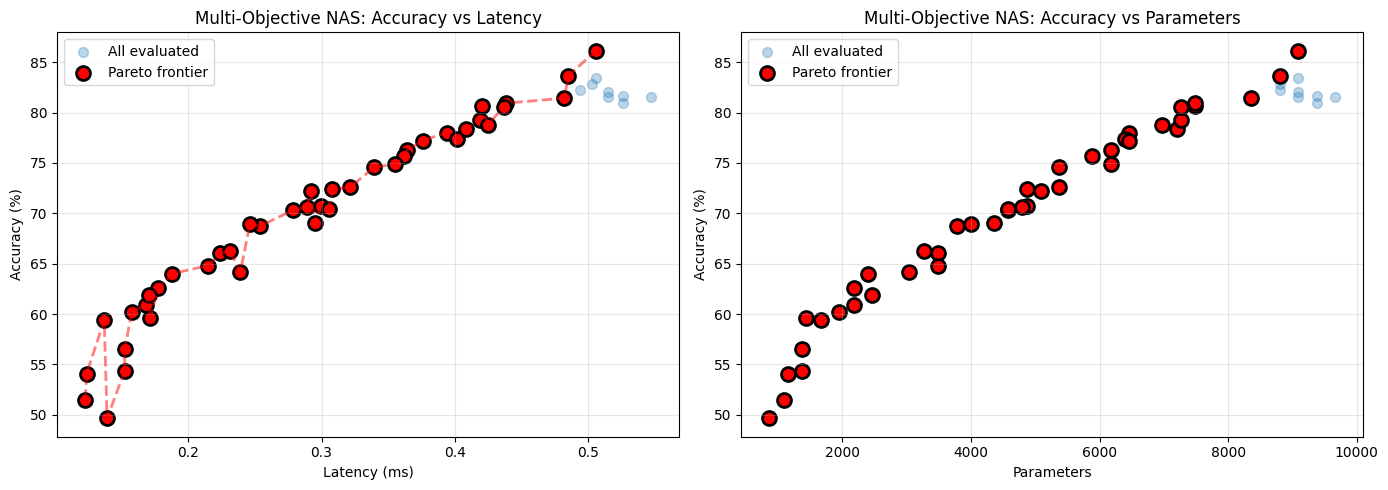

In [29]:
# Visualize Pareto frontier

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All evaluated architectures
all_accs = [a.accuracy for a in mo_nas.population]
all_lats = [a.latency for a in mo_nas.population]
pareto_accs = [a.accuracy for a in pareto_front]
pareto_lats = [a.latency for a in pareto_front]

# Plot 1: Accuracy vs Latency
ax = axes[0]
ax.scatter(all_lats, [100*a for a in all_accs], alpha=0.3, s=50, label='All evaluated')
ax.scatter(pareto_lats, [100*a for a in pareto_accs], c='red', s=100,
           label='Pareto frontier', edgecolors='black', linewidth=2)

# Connect Pareto points
pareto_sorted = sorted(zip(pareto_lats, pareto_accs))
ax.plot([p[0] for p in pareto_sorted], [100*p[1] for p in pareto_sorted],
        'r--', alpha=0.5, linewidth=2)

ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Multi-Objective NAS: Accuracy vs Latency')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Accuracy vs Parameters
ax = axes[1]
all_params = [a.params for a in mo_nas.population]
pareto_params = [a.params for a in pareto_front]

ax.scatter(all_params, [100*a for a in all_accs], alpha=0.3, s=50, label='All evaluated')
ax.scatter(pareto_params, [100*a for a in pareto_accs], c='red', s=100,
           label='Pareto frontier', edgecolors='black', linewidth=2)

ax.set_xlabel('Parameters')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Multi-Objective NAS: Accuracy vs Parameters')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

Hardware-Aware Search

Combining accuracy optimization with hardware constraints. The key insight: include latency in the reward/loss function.

In [30]:
class HardwareAwareNAS:
    """
    NAS with hard latency constraint.

    Objective: max accuracy subject to latency <= target
    """

    def __init__(self, num_ops: int, num_nodes: int,
                 latency_lut: LatencyLookupTable,
                 target_latency: float):
        self.num_ops = num_ops
        self.num_nodes = num_nodes
        self.num_edges = sum(i + 2 for i in range(num_nodes))
        self.latency_lut = latency_lut
        self.target_latency = target_latency
        self.history = []

    def _random_architecture(self) -> np.ndarray:
        return np.random.randint(0, self.num_ops, self.num_edges)

    def _estimate_latency(self, arch: np.ndarray, base_channels: int = 32) -> float:
        total = 0
        for op_idx in arch:
            if op_idx < 2:
                latency = 0.001
            elif op_idx < 6:
                k = 3 if op_idx in [2, 4] else 5
                latency = self.latency_lut.get_latency('conv',
                    (base_channels, base_channels, k, 16, 1, base_channels))
            else:
                latency = 0.01
            total += latency
        return total

    def _simulate_accuracy(self, arch: np.ndarray) -> float:
        """Simulate accuracy (in practice, would train and evaluate)."""
        # More complex ops tend to have higher accuracy
        complexity = sum(1 for op in arch if op >= 2 and op < 6)
        base_acc = 0.5 + 0.35 * (complexity / self.num_edges)
        noise = np.random.normal(0, 0.02)
        return min(0.95, max(0.4, base_acc + noise))

    def _compute_reward(self, arch: np.ndarray) -> Tuple[float, float, float]:
        """
        Compute reward with latency penalty.

        reward = accuracy - λ * max(0, latency - target)^2
        """
        accuracy = self._simulate_accuracy(arch)
        latency = self._estimate_latency(arch)

        # Penalty for exceeding target latency
        latency_penalty = max(0, latency - self.target_latency) ** 2
        lambda_penalty = 10.0  # Penalty weight

        reward = accuracy - lambda_penalty * latency_penalty

        return reward, accuracy, latency

    def search(self, num_iterations: int = 50,
               strategy: str = 'evolutionary') -> Tuple[np.ndarray, float, float]:
        """
        Hardware-aware search.
        """
        best_arch = None
        best_reward = float('-inf')
        best_acc = 0
        best_lat = float('inf')

        if strategy == 'evolutionary':
            # Initialize population
            population = [(self._random_architecture(), *self._compute_reward(self._random_architecture())[:3])
                         for _ in range(20)]

            for iteration in range(num_iterations):
                # Sort by reward
                population.sort(key=lambda x: x[1], reverse=True)

                # Update best (only if meets latency constraint)
                for arch, reward, acc, lat in population:
                    if lat <= self.target_latency and reward > best_reward:
                        best_arch = arch
                        best_reward = reward
                        best_acc = acc
                        best_lat = lat

                # Create offspring from top half
                new_population = population[:10]
                while len(new_population) < 20:
                    parent1 = random.choice(population[:10])[0]
                    parent2 = random.choice(population[:10])[0]

                    # Crossover
                    mask = np.random.rand(self.num_edges) < 0.5
                    child = np.where(mask, parent1, parent2)

                    # Mutation
                    for i in range(len(child)):
                        if random.random() < 0.1:
                            child[i] = random.randint(0, self.num_ops - 1)

                    reward, acc, lat = self._compute_reward(child)
                    new_population.append((child, reward, acc, lat))

                population = new_population
                self.history.append({
                    'iteration': iteration,
                    'best_acc': best_acc,
                    'best_lat': best_lat,
                    'meets_constraint': best_lat <= self.target_latency
                })

                if (iteration + 1) % 10 == 0:
                    constraint_met = "✓" if best_lat <= self.target_latency else "✗"
                    print(f"Iter {iteration+1}: acc={100*best_acc:.1f}%, "
                          f"lat={best_lat:.3f}ms (target={self.target_latency}ms) {constraint_met}")

        return best_arch, best_acc, best_lat

In [31]:
# Search with different latency constraints

print("=" * 60)
print("HARDWARE-AWARE NAS WITH LATENCY CONSTRAINTS")
print("=" * 60)

latency_targets = [0.5, 1.0, 2.0, 5.0]  # ms
results = {}

for target in latency_targets:
    print(f"\n--- Target Latency: {target}ms ---")

    hw_nas = HardwareAwareNAS(
        num_ops=8, num_nodes=4,
        latency_lut=lut_mobile,
        target_latency=target
    )

    arch, acc, lat = hw_nas.search(num_iterations=30)
    results[target] = {'arch': arch, 'accuracy': acc, 'latency': lat}

# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\n{'Target (ms)':<15} {'Accuracy':>10} {'Actual (ms)':>12} {'Met?':>8}")
print("-" * 50)
for target, r in results.items():
    met = "✓" if r['latency'] <= target else "✗"
    print(f"{target:<15} {100*r['accuracy']:>9.1f}% {r['latency']:>11.3f}ms {met:>8}")

HARDWARE-AWARE NAS WITH LATENCY CONSTRAINTS

--- Target Latency: 0.5ms ---
Iter 10: acc=83.0%, lat=0.425ms (target=0.5ms) ✓
Iter 20: acc=85.3%, lat=0.402ms (target=0.5ms) ✓
Iter 30: acc=89.8%, lat=0.414ms (target=0.5ms) ✓

--- Target Latency: 1.0ms ---
Iter 10: acc=82.6%, lat=0.438ms (target=1.0ms) ✓
Iter 20: acc=88.5%, lat=0.436ms (target=1.0ms) ✓
Iter 30: acc=88.9%, lat=0.459ms (target=1.0ms) ✓

--- Target Latency: 2.0ms ---
Iter 10: acc=79.3%, lat=0.406ms (target=2.0ms) ✓
Iter 20: acc=86.4%, lat=0.469ms (target=2.0ms) ✓
Iter 30: acc=86.7%, lat=0.503ms (target=2.0ms) ✓

--- Target Latency: 5.0ms ---
Iter 10: acc=80.0%, lat=0.395ms (target=5.0ms) ✓
Iter 20: acc=85.1%, lat=0.393ms (target=5.0ms) ✓
Iter 30: acc=87.1%, lat=0.459ms (target=5.0ms) ✓

SUMMARY

Target (ms)       Accuracy  Actual (ms)     Met?
--------------------------------------------------
0.5                  89.8%       0.414ms        ✓
1.0                  88.9%       0.459ms        ✓
2.0                  86.7%       0

Cross-Platform Comparison

The same accuracy target yields different optimal architectures for different hardware.

In [32]:
# Search for best architecture on different platforms

print("=" * 70)
print("CROSS-PLATFORM NAS COMPARISON")
print("=" * 70)

platforms = ['gpu_v100', 'cpu_server', 'gpu_mobile', 'cpu_mobile', 'edge_npu']
platform_results = {}

# Same relative latency budget (1.5ms on mobile)
mobile_target = 1.5

for platform in platforms:
    print(f"\n--- Platform: {HARDWARE_PROFILES[platform].name} ---")

    # Scale target latency by relative speed
    scale_factor = (HARDWARE_PROFILES[platform].conv_speed /
                   HARDWARE_PROFILES['cpu_mobile'].conv_speed)
    scaled_target = mobile_target * scale_factor

    lut = LatencyLookupTable(platform)
    lut.build_table_for_search_space([16, 32, 64, 128], [32, 16, 8])

    hw_nas = HardwareAwareNAS(
        num_ops=8, num_nodes=4,
        latency_lut=lut,
        target_latency=scaled_target
    )

    arch, acc, lat = hw_nas.search(num_iterations=20)

    platform_results[platform] = {
        'arch': arch,
        'accuracy': acc,
        'latency': lat,
        'target': scaled_target
    }

CROSS-PLATFORM NAS COMPARISON

--- Platform: NVIDIA V100 ---
Built lookup table with 180 entries
Iter 10: acc=85.4%, lat=0.002ms (target=75.0ms) ✓
Iter 20: acc=90.9%, lat=0.001ms (target=75.0ms) ✓

--- Platform: Intel Xeon ---
Built lookup table with 180 entries
Iter 10: acc=83.9%, lat=0.045ms (target=3.75ms) ✓
Iter 20: acc=89.2%, lat=0.047ms (target=3.75ms) ✓

--- Platform: Mobile GPU (Adreno) ---
Built lookup table with 180 entries
Iter 10: acc=82.9%, lat=0.214ms (target=7.5ms) ✓
Iter 20: acc=83.4%, lat=0.220ms (target=7.5ms) ✓

--- Platform: ARM Cortex-A76 ---
Built lookup table with 180 entries
Iter 10: acc=85.6%, lat=0.402ms (target=1.5ms) ✓
Iter 20: acc=88.3%, lat=0.365ms (target=1.5ms) ✓

--- Platform: Edge NPU ---
Built lookup table with 180 entries
Iter 10: acc=80.4%, lat=0.185ms (target=22.5ms) ✓
Iter 20: acc=87.7%, lat=0.194ms (target=22.5ms) ✓


In [33]:
# Compare architectures across platforms

print("\n" + "=" * 80)
print("CROSS-PLATFORM RESULTS")
print("=" * 80)

op_names = ['none', 'skip', 'sep3', 'sep5', 'dil3', 'dil5', 'avg', 'max']

print(f"\n{'Platform':<20} {'Accuracy':>10} {'Latency':>12} {'Target':>10}")
print("-" * 55)

for platform, r in platform_results.items():
    name = HARDWARE_PROFILES[platform].name[:18]
    met = "✓" if r['latency'] <= r['target'] else "✗"
    print(f"{name:<20} {100*r['accuracy']:>9.1f}% {r['latency']:>10.4f}ms "
          f"{r['target']:>9.4f}ms {met}")

# Analyze operation preferences by platform
print("\n" + "=" * 80)
print("OPERATION PREFERENCES BY PLATFORM")
print("=" * 80)

print(f"\n{'Platform':<20}", end='')
for op in op_names:
    print(f"{op:>8}", end='')
print()
print("-" * 85)

for platform, r in platform_results.items():
    name = HARDWARE_PROFILES[platform].name[:18]
    print(f"{name:<20}", end='')

    # Count operations
    counts = np.bincount(r['arch'], minlength=8)
    for c in counts:
        print(f"{c:>8}", end='')
    print()


CROSS-PLATFORM RESULTS

Platform               Accuracy      Latency     Target
-------------------------------------------------------
NVIDIA V100               90.9%     0.0013ms   75.0000ms ✓
Intel Xeon                89.2%     0.0465ms    3.7500ms ✓
Mobile GPU (Adreno        83.4%     0.2203ms    7.5000ms ✓
ARM Cortex-A76            88.3%     0.3648ms    1.5000ms ✓
Edge NPU                  87.7%     0.1936ms   22.5000ms ✓

OPERATION PREFERENCES BY PLATFORM

Platform                none    skip    sep3    sep5    dil3    dil5     avg     max
-------------------------------------------------------------------------------------
NVIDIA V100                0       0       1       4       4       5       0       0
Intel Xeon                 0       0       2       6       0       6       0       0
Mobile GPU (Adreno         0       1       5       3       5       0       0       0
ARM Cortex-A76             0       0       4       2       6       2       0       0
Edge NPU             

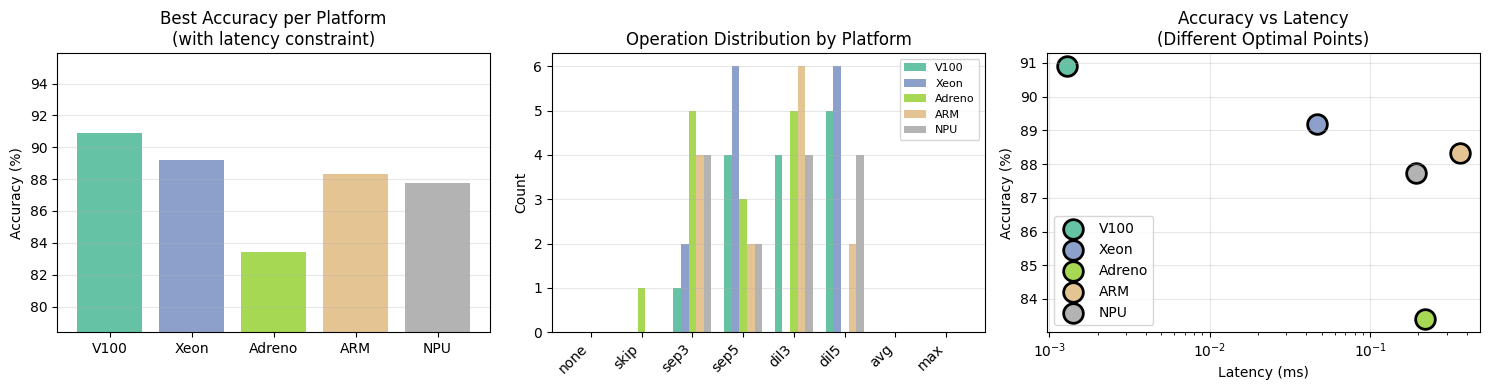

In [34]:
# Visualize cross-platform comparison

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

platforms_short = ['V100', 'Xeon', 'Adreno', 'ARM', 'NPU']
accs = [platform_results[p]['accuracy'] * 100 for p in platforms]
lats = [platform_results[p]['latency'] for p in platforms]

# Plot 1: Accuracy by platform
ax = axes[0]
colors = plt.cm.Set2(np.linspace(0, 1, len(platforms)))
ax.bar(platforms_short, accs, color=colors)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Best Accuracy per Platform\n(with latency constraint)')
ax.set_ylim(min(accs) - 5, max(accs) + 5)
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Operation distribution
ax = axes[1]
op_counts = np.array([np.bincount(platform_results[p]['arch'], minlength=8)
                      for p in platforms])
x = np.arange(len(op_names))
width = 0.15

for i, (p, c) in enumerate(zip(platforms_short, colors)):
    ax.bar(x + i * width, op_counts[i], width, label=p, color=c)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(op_names, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Operation Distribution by Platform')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Accuracy vs Latency
ax = axes[2]
for i, (p, c, pname) in enumerate(zip(platforms, colors, platforms_short)):
    r = platform_results[p]
    ax.scatter(r['latency'], r['accuracy'] * 100, s=200, c=[c],
               edgecolors='black', linewidth=2, label=pname)

ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Latency\n(Different Optimal Points)')
ax.legend()
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cross_platform_nas.png', dpi=150, bbox_inches='tight')
plt.show()